### Proyecto para clasificar tubérculos de papa basado en el estado de estas (buen estado y defectuoso)

Para ello se utilizará un modelo preentrenado **Vision Transformer (ViT-B16)**.

**Dataset Híbrido**: 36000 imágenes de papas clasificadas en dos categorías:

- ✅ Buen estado (calidad aceptable)
- ❌ Defectuoso (cortadas, con brotes, podridas)


#### Importación de Librerías y configuración

Importamos las librerías necesarias para el procesamiento de imágenes, entrenamiento del modelo ViT y evaluación de resultados.


In [1]:
%pip install torchmetrics torchvision grad-cam

In [2]:
import os, math, warnings
import zipfile
import shutil
from typing import Dict, Tuple, Callable, Optional, Any
from pathlib import Path
import numpy as np
import timm
import torch
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from dataclasses import dataclass
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from PIL import Image
from timm.data import create_transform

from torchvision import datasets, transforms
from google.colab import drive

from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score, MulticlassRecall, MulticlassPrecision
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import LambdaLR

warnings.filterwarnings("ignore")

dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", dispositivo)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    if torch.cuda.get_device_capability()[0] >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        print("TF32 habilitado")

# Semilla
def configurar_semilla(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

configurar_semilla(42)

Dispositivo: cuda
GPU: Tesla T4


#### Cargar Dataset
En esta sección se carga el dataset y se divide en un 80% para entrenamiento y un 20% para prueba. Posteriormente, dentro del conjunto de entrenamiento, se realiza una subdivisión del 80% para entrenamiento y el 20% restante para validación.

In [ ]:
# montar carpeta google drive
drive.mount('/content/drive')

DATA_DIR_ZIP = Path("/content/drive/MyDrive/Datos_ViT/Datos/dataset_papas_hibrido.zip")
DIR_EXTRACCION = Path("/content")
DATA_DIR_DIV = Path("/content/dataset_papas")
DATA_DIR_ORIG = Path("/content/dataset_papas_hibrido")

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def es_imagen(p: Path) -> bool:
    return p.is_file() and p.suffix.lower() in IMG_EXTS

def obtener_clases_desde(direct_raiz: Path):
    return sorted([d.name for d in direct_raiz.iterdir() if d.is_dir()])

def split_valido(direct_raiz: Path) -> bool:
    # Espera estructura: root/train, root/val, root/test con subcarpetas por clase
    sub_conjuntos = ["train", "val", "test"]
    if not all((direct_raiz / s).is_dir() for s in sub_conjuntos):
        return False

    clases_train = obtener_clases_desde(direct_raiz / "train")
    clases_val = obtener_clases_desde(direct_raiz / "val")
    clases_test = obtener_clases_desde(direct_raiz / "test")

    if not clases_train or clases_train != clases_val or clases_train != clases_test:
        return False

    # Validar que cada sub_conjunto tenga al menos una imagen por clase
    for s in sub_conjuntos:
        for c in clases_train:
            dir_clase = direct_raiz / s / c
            if not dir_clase.is_dir():
                return False
            if not any(es_imagen(p) for p in dir_clase.iterdir()):
                return False
    return True

def dataset_plano_valido(direct_raiz: Path) -> bool:
    # Espera estructura: root/clase_1, root/clase_2, ... (sin train/val/test)
    if not direct_raiz.is_dir():
        return False
    clases = [d for d in direct_raiz.iterdir() if d.is_dir() and d.name not in {"train", "val", "test"}]
    if len(clases) < 2:
        return False
    return any(any(es_imagen(p) for p in c.iterdir()) for c in clases)

def dividir_dataset(origen: Path, destino_split: Path, tamanio_test=0.2, val_size_sobre_train=0.2, seed=42):
    TRAIN_DIR = destino_split / "train"
    VAL_DIR = destino_split / "val"
    TEST_DIR = destino_split / "test"

    for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
        d.mkdir(parents=True, exist_ok=True)

    clases = [d.name for d in origen.iterdir() if d.is_dir() and d.name not in {"train", "val", "test"}]

    for nombre_clase in clases:
        dir_clase = origen / nombre_clase
        imagenes = [p.name for p in dir_clase.iterdir() if es_imagen(p)]

        train_temp, test_imgs = train_test_split(
            imagenes, tamanio_test=tamanio_test, random_state=seed, shuffle=True
        )
        train_imgs, val_imgs = train_test_split(
            train_temp, tamanio_test=val_size_sobre_train, random_state=seed, shuffle=True
        )

        for dir_division, imgs_division in [
            (TRAIN_DIR, train_imgs),
            (VAL_DIR, val_imgs),
            (TEST_DIR, test_imgs),
        ]:
            clase_dest = dir_division / nombre_clase
            clase_dest.mkdir(parents=True, exist_ok=True)
            for img in imgs_division:
                src = dir_clase / img
                dst = clase_dest / img
                if not dst.exists():
                    shutil.copy2(src, dst)

    return TRAIN_DIR, VAL_DIR, TEST_DIR

# descomprimir
with zipfile.ZipFile(DATA_DIR_ZIP, "r") as zip_ref:
    zip_ref.extractall(DIR_EXTRACCION)

# resolver automáticamente rutas de train/val/test
if split_valido(DATA_DIR_ORIG):
    # El zip ya venía dividido
    TRAIN_DIR = DATA_DIR_ORIG / "train"
    VAL_DIR = DATA_DIR_ORIG / "val"
    TEST_DIR = DATA_DIR_ORIG / "test"
    print(f"Dataset ya dividido en {DATA_DIR_ORIG}.")
elif split_valido(DATA_DIR_DIV):
    # Ya existía una versión dividida en la ruta destino
    TRAIN_DIR = DATA_DIR_DIV / "train"
    VAL_DIR = DATA_DIR_DIV / "val"
    TEST_DIR = DATA_DIR_DIV / "test"
    print(f"Dataset ya dividido en {DATA_DIR_DIV}")
else:
    # No está dividido: dividir y guardar en DATA_DIR_DIV
    if not dataset_plano_valido(DATA_DIR_ORIG):
        raise RuntimeError(f"No se encontró estructura válida en: {DATA_DIR_ORIG}")
    TRAIN_DIR, VAL_DIR, TEST_DIR = dividir_dataset(DATA_DIR_ORIG, DATA_DIR_DIV)
    print("Dataset dividido en train/val/test.")

# Data augmentation SOLO en train (robustez)
transformaciones_vit_train = create_transform(
    input_size=(3, 224, 224),
    is_training=True,
    auto_augment="rand-m9-mstd0.5-inc1", # autoaumentación aleatoria -> mejorar generalización (rotaciones, recortes, cambios de color, contraste, brillo, etc.)
    re_prob=0.25, # enmascarado aleatorio de parches -> evitar que el modelo dependa de una sola parte de la imagen
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225),
)

transformaciones_vit_val = create_transform(
    input_size=(3, 224, 224),
    is_training=False,
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225),
)

# Crear Datasets 
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=transformaciones_vit_train)
val_ds = datasets.ImageFolder(VAL_DIR, transform=transformaciones_vit_val)
test_ds = datasets.ImageFolder(TEST_DIR, transform=transformaciones_vit_val)


BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() or 0)
PIN_MEMORY = dispositivo.type == "cuda"

# crear DataLoaders
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

total = len(train_ds) + len(val_ds) + len(test_ds)
print("Clases:", train_ds.classes)
print(f"Datos totales {total} -> 100%")
print(
    f"Train: {len(train_ds)} ({len(train_ds)/total*100:.2f}%) | "
    f"Val: {len(val_ds)} ({len(val_ds)/total*100:.2f}%) | "
    f"Test: {len(test_ds)} ({len(test_ds)/total*100:.2f}%)
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Carpeta creada: /content/dataset_papas/train
Carpeta creada: /content/dataset_papas/val
Carpeta creada: /content/dataset_papas/test
Clases: ['Buen estado', 'Defectuoso']
Datos totales 8836 -> 100%
Cantidad de datos en Train: 5654 -> 63.99% | Val: 1414 -> 16.00% | Test: 1768 -> 20.01%


#### Configuración del Modelo ViT (Transfer Learning)

Cargamos **Vision Transformer Base (ViT-B16)** con pesos preentrenados de ImageNet-1K.

**Estrategia de Transfer Learning**:
- Congelamos el backbone completo (embeddings + encoder)
- Solo entrenamos la cabeza clasificadora (2 clases: buen estado, defectuoso)
- Resultado: ~1,538 parámetros entrenables vs ~85M congelados

In [ ]:
"""
    num_clases (int): número de clases de salida.
    capas_descongelar (int): número de capas del backbone a descongelar.
        - 0: modelo base (solo la cabeza entrenable).
        - 1: transfer learning mínimo (última capa).
        - 6: fine-tuning parcial.
        - 12: fine-tuning total.
"""
class ClasificadorPapasViT(nn.Module):
    def __init__(self,
                 num_clases: int = 2,
                 capas_descongelar: int = 0):

        super().__init__()

        # Crear modelo ViT base con pesos preentrenados
        self.backbone = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            num_classes=num_clases,
        )

        # Inicializar explícitamente la nueva cabeza de clasificación
        nn.init.xavier_uniform_(self.backbone.head.weight)  # pesos con distribución estable
        nn.init.zeros_(self.backbone.head.bias)             # sesgos en cero

        # congelar todo el backbone excepto la cabeza
        for name, p in self.backbone.named_parameters():
            if "head" not in name:
                p.requires_grad = False

        # descongelar las últimas N capas si se especifica
        if capas_descongelar > 0:
            encoder_layers = list(self.backbone.blocks)  # bloques del encoder ViT
            # Seleccionamos las últimas N capas y las hacemos entrenables
            for layer in encoder_layers[-capas_descongelar:]:
                for p in layer.parameters():
                    p.requires_grad = True

    def forward(self, valores_pixel: torch.Tensor) -> torch.Tensor:
        # Forward directo al backbone
        return self.backbone(valores_pixel)

# crear modelo para Transfer Learning
modelo = ClasificadorPapasViT(num_clases=2, capas_descongelar=0).to(dispositivo)

# Opcional: compilar (PyTorch 2.0+)
if hasattr(torch, "compile") and dispositivo.type == "cuda":
    modelo = torch.compile(modelo)

# Info rápida
entrenables = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
total = sum(p.numel() for p in modelo.parameters())
print(
    f"Parámetros entrenables: {entrenables:,} / {total:,} ({100*entrenables/total:.4f}%)"
)

Parámetros entrenables: 1,538 / 85,800,194 (0.0018%)


#### Configuración de Hiperparámetros

---
En esta sección se configuran los hiperparámetros necesarios para que el modelo aprenda de manera óptima y logre una convergencia más rápida y eficiente, utilizando optimizadores como AdamW. Los hiperparámetros definidos son:

* Número de épocas.
* Tasa de aprendizaje (learning rate).
* Weight Decay o regularización de pesos.
* Parámetros Beta (B1 y B2).
* Uso de precisión mixta según el dispositivo disponible.






In [ ]:
 # Configuración de hiperparámetros para entrenamiento.
@dataclass
class ConfigEntrenamiento:
    epocas: int = 30
    lr: float = 1e-5
    weight_decay: float = 1e-4 
    batch_size: int = 32
    warmup_frac: float = 0.5
    betas: Tuple[float, float] = (0.9, 0.999)
    mixed_precision: bool = True
    metrica_principal: str = "f1"

    def __str__(self):
        return (
            f"Configuración:\n"
            f"Épocas: {self.epocas}\n"
            f"Learning Rate: {self.lr}\n"
            f"Weight Decay: {self.weight_decay}\n"
            f"Batch Size: {self.batch_size}\n"
            f"Mixed Precision: {self.mixed_precision}\n"
            f"Betas: {self.betas}\n"
            f"Warmup Frac: {self.warmup_frac}\n"
            f"Métrica Principal: {self.metrica_principal}\n"
        )

#### Configuración de Entrenamiento
---
Definimos hiperparámetros y objetos necesarios para el entrenamiento:
- **Optimizador**: AdamW con weight decay para regularización
- **programador**: Linear con warmup (50% de los pasos)
- **Mixed Precision**: AMP (Precisión Mixta Automática) para eficiencia en GPU
- **Métricas**: Accuracy, Recall, Precision y F1-Score con torchmetrics

In [ ]:
# criterio_perdida de pérdida
criterio_perdida = nn.CrossEntropyLoss()
# configuración
config = ConfigEntrenamiento()
# mostrar configuración
display(config)
# Programador con warmup lineal
pasos_totales = config.epocas * max(1, len(train_loader))
warmup_pasos = int(config.warmup_frac * pasos_totales)
# Optimizador
optimizador = optim.AdamW(
    [p for p in modelo.parameters() if p.requires_grad],
    lr=config.lr,
    betas=config.betas,
    weight_decay=config.weight_decay,
)


# lambda para que el programador ajuste el LR con warmup lineal
def lr_lambda(paso):
    if paso < warmup_pasos:
        return float(paso) / float(max(1, warmup_pasos))
    return max(
        0.0, float(pasos_totales - paso) / float(max(1, pasos_totales - warmup_pasos))
    )


programador = LambdaLR(optimizador, lr_lambda)

# AMP Scaler para precisión mixta y mejor rendimiento
escala = GradScaler(enabled=config.mixed_precision)

# Métricas con torchmetrics
num_clases = 2
acc_metrica = MulticlassAccuracy(num_classes=num_clases, average="weighted").to(
    dispositivo
)
f1_metrica = MulticlassF1Score(num_classes=num_clases, average="weighted").to(
    dispositivo
)
recall_metrica = MulticlassRecall(num_classes=num_clases, average="weighted").to(
    dispositivo
)
precision_metrica = MulticlassPrecision(num_classes=num_clases, average="weighted").to(
    dispositivo
)

# Checkpoint dirección
CHECKPOINT_RUTA = Path("/content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_tl.pt")
CHECKPOINT_FT = Path("/content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_ft.pt")
CHECKPOINT_RUTA.parent.mkdir(parents=True, exist_ok=True)
CHECKPOINT_FT.parent.mkdir(parents=True, exist_ok=True)
print(f"\nCheckpoint se guardará en: {CHECKPOINT_RUTA.as_posix()}")
print(f"Checkpoint Fine-Tuning se guardará en: {CHECKPOINT_FT.as_posix()}")
print(f"Pasos totales: {pasos_totales} (warmup: {warmup_pasos} pasos)")

ConfigEntrenamiento(epocas=30, lr=1e-05, weight_decay=0.0001, batch_size=32, warmup_frac=0.5, betas=(0.9, 0.999), mixed_precision=True, metrica_principal='f1')


Checkpoint se guardará en: /content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_tl.pt
Checkpoint Fine-Tuning se guardará en: /content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_ft.pt
Pasos totales: 5310 (warmup: 2655 pasos)


In [7]:
# Crea diccionario con métricas de clasificación
def crear_metricas(num_clases: int = 2, dispositivo: torch.device = torch.device("cpu")) -> Dict[str, Any]:
    return {
        "acc": MulticlassAccuracy(num_classes=num_clases, average="weighted").to(dispositivo),
        "f1": MulticlassF1Score(num_classes=num_clases, average="weighted").to(dispositivo),
        "precision": MulticlassPrecision(num_classes=num_clases, average="weighted").to(dispositivo),
        "recall": MulticlassRecall(num_classes=num_clases, average="weighted").to(dispositivo)
    }

#### Entrenar capas de clasificación - Transfer Learning
---
En esta sección se reentrena la capa final de clasificación del modelo ViT-Base/16 mediante la técnica de Transfer Learning, utilizando los conjuntos de entrenamiento y validación previamente separados. Durante el proceso de reentrenamiento se calcula la función de pérdida y la precisión en cada época, y con base en estos resultados se actualiza y guarda el mejor modelo alcanzado.

In [ ]:
import pandas as pd
from tqdm import tqdm


def iterar_epoca(
    modelo: nn.Module,
    loader: DataLoader,
    criterio_perdida: nn.Module,
    metricas: Dict[str, Any],
    dispositivo: torch.device,
    optimizador: Optional[optim.Optimizer],
    escala: Optional[GradScaler] = None,
    programador: Optional[LambdaLR] = None,
    entrenar: bool = True,
    mixed_precision: bool = True,
) -> Dict[str, float]:

    modelo.train(mode=entrenar)
    # reset métricas
    for metrica in metricas.values():
        metrica.reset()
    perdidas = []
    descripcion = "Train" if entrenar else "Val"

    for batch in tqdm(loader, leave=False, desc=descripcion):
        imagenes, etiquetas = batch[0].to(dispositivo, non_blocking=True), batch[1].to(
            dispositivo, non_blocking=True
        )

        with torch.set_grad_enabled(entrenar):
            with autocast(enabled=mixed_precision):
                salida = modelo(valores_pixel=imagenes)
                perdida = criterio_perdida(salida, etiquetas)

            if entrenar:
                optimizador.zero_grad(set_to_none=True)
                escala.scale(perdida).backward()
                escala.step(optimizador)
                escala.update()
                # verificar si programador no es None para evitar error
                if programador is not None:
                    programador.step()

        perdidas.append(perdida.detach().item())
        predicciones = salida.detach().argmax(dim=1)

        # actualizar métricas
        for metrica in metricas.values():
            metrica.update(predicciones, etiquetas)

    # calcular métricas finales
    resultados = {
        "perdida": float(np.mean(perdidas)) if perdidas else math.nan,
    }
    for nombre, metrica in metricas.items():
        resultados[nombre] = float(metrica.compute().item())
    return resultados


# metodo de entrenamiento
def entrenar_modelo(
    modelo: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterio_perdida: nn.Module,
    optimizador: optim.Optimizer,
    metricas: Dict[str, Any],
    config: ConfigEntrenamiento,
    ruta_ckpt: Path,
    dispositivo: torch.device,
    programador: Optional[LambdaLR] = None,
    escala: Optional[GradScaler] = None,
    callback_epoca: Optional[Callable] = None,
    descripcion: bool = True,
) -> Tuple[pd.DataFrame, Dict[str, float]]:
    mejor_metrica = -1.0
    mejor_epoca = -1
    mejor_perdida = float("inf")
    historia = []

    if descripcion:
        print("Iniciando entrenamiento...\n")
        print("=====" * 20)
        print(config)
        print(f"Metrica principal {config.metrica_principal}\n")
        print(f"Ruta checkpoint: {ruta_ckpt.as_posix()}\n")
        print("=====" * 20)
    for epoca in range(1, config.epocas + 1):
        # entrenamiento
        metricas_train = iterar_epoca(
            modelo,
            train_loader,
            criterio_perdida,
            metricas,
            dispositivo,
            optimizador,
            escala,
            programador,
            entrenar=True,
            mixed_precision=config.mixed_precision,
        )
        # validación
        metricas_val = iterar_epoca(
            modelo=modelo,
            loader=val_loader,
            optimizador=None,
            criterio_perdida=criterio_perdida,
            metricas=metricas,
            dispositivo=dispositivo,
            entrenar=False,
            mixed_precision=config.mixed_precision,
        )
        # registrar historia
        registro = {"epoca": epoca}
        for nombre, valor in metricas_train.items():
            registro[f"train_{nombre}"] = valor
        for nombre, valor in metricas_val.items():
            registro[f"val_{nombre}"] = valor
        historia.append(registro)

        # callback por época
        if callback_epoca:
            callback_epoca(epoca, metricas_train, metricas_val)
        # imprimir resultados
        if descripcion:
            print(f"Época {epoca:02d}/{config.epocas} | ")
            print(
                f"Train → {' | '.join([f'{k}: {v:.4f}' for k, v in metricas_train.items()])}"
            )
            print(
                f"Val → {' | '.join([f'{k}: {v:.4f}' for k, v in metricas_val.items()])}"
            )
        # guardar mejor modelo
        metrica_actual = metricas_val[config.metrica_principal]
        perdida_actual = metricas_val["perdida"]
        mejorado = False
        if config.metrica_principal == "perdida":
            if perdida_actual < mejor_perdida:
                mejorado = True
        else:
            if (metrica_actual > mejor_metrica) or (
                metrica_actual == mejor_metrica and perdida_actual < mejor_perdida
            ):
                mejorado = True

        if mejorado:
            mejor_metrica = metrica_actual
            mejor_epoca = epoca
            mejor_perdida = perdida_actual
            # guardar checkpoint completo
            torch.save(
                {
                    "epoca": epoca,
                    "modelo_state_dict": modelo.state_dict(),
                    "optimizador_state_dict": optimizador.state_dict(),
                    "mejor_metrica": mejor_metrica,
                    "mejor_perdida": mejor_perdida,
                    "metricas_train": metricas_train,
                    "metricas_val": metricas_val,
                },
                ruta_ckpt,
            )
            # guardar solo pesos del modelo
            ruta_pesos = ruta_ckpt.with_name(ruta_ckpt.stem + "_pesos.pt")
            torch.save(modelo.state_dict(), ruta_pesos)
        if descripcion:
            if mejorado:
                print(
                    f"✓ Mejor modelo guardado (época {epoca}) → {ruta_ckpt.as_posix()}"
                )
                print(f"F1-Score: {mejor_metrica:.4f}")
            print("-----" * 20)
    if descripcion:
        print("Entrenamiento finalizado.")
        print(f"{'====='*20}")
        print(
            f"Mejor {config.metrica_principal}: {mejor_metrica:.4f} (época {mejor_epoca})"
        )
        print(f"Mejor pérdida: {mejor_perdida:.6f}")
        print(f"{'====='*20}\n")

    # crear DataFrame de historia
    df_historia = pd.DataFrame(historia)
    mejores_metricas = {
        "epoca": mejor_epoca,
        config.metrica_principal: mejor_metrica,
        "perdida": mejor_perdida,
    }

    return df_historia, mejores_metricas

# ================================================
# configuración de ENTRENAMIENTO TRANSFER LEARNING
# ================================================
config_tlr = ConfigEntrenamiento(
    epocas=30,
    lr=1e-5,
    weight_decay=1e-2,
    batch_size=BATCH_SIZE,
    warmup_frac=0.5,
    mixed_precision=True,
    metrica_principal="f1",
)

# crear métricas
metricas = crear_metricas(num_clases=2, dispositivo=dispositivo)

# entrenar modelo
historia_tl, mejores_metricas_tl = entrenar_modelo(
    modelo=modelo,
    train_loader=train_loader,
    val_loader=val_loader,
    criterio_perdida=criterio_perdida,
    optimizador=optimizador,
    metricas=metricas,
    config=config_tlr,
    ruta_ckpt=CHECKPOINT_RUTA,
    dispositivo=dispositivo,
    programador=programador,
    escala=escala,
    descripcion=True,
)

# mostrar métricas
display(historia_tl)

Iniciando entrenamiento...

Configuración:
Épocas: 30
Learning Rate: 1e-05
Weight Decay: 0.01
Batch Size: 32
Mixed Precision: True
Betas: (0.9, 0.999)
Warmup Frac: 0.5
Métrica Principal: f1

Metrica principal f1

Ruta checkpoint: /content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_tl.pt



Época 01/30 | 
Train → perdida: 1.1375 | acc: 0.4910 | f1: 0.4963 | precision: 0.5902 | recall: 0.4910
Val → perdida: 1.0915 | acc: 0.4873 | f1: 0.5007 | precision: 0.5486 | recall: 0.4873
✓ Mejor modelo guardado (época 1) → /content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_tl.pt
F1-Score: 0.5007
----------------------------------------------------------------------------------------------------


Época 02/30 | 
Train → perdida: 1.0975 | acc: 0.4956 | f1: 0.5033 | precision: 0.5865 | recall: 0.4956
Val → perdida: 1.0585 | acc: 0.5000 | f1: 0.5136 | precision: 0.5545 | recall: 0.5000
✓ Mejor modelo guardado (época 2) → /content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_tl.pt
F1-Score: 0.5136
----------------------------------------------------------------------------------------------------


Época 03/30 | 
Train → perdida: 1.0612 | acc: 0.5085 | f1: 0.5188 | precision: 0.5882 | recall: 0.5085
Val → perdida: 1.0092 | acc: 0.5127 | f1: 0.5256 | precision: 0.5553 | recall: 0.5127
✓ Mejor modelo guardado (época 3) → /content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_tl.pt
F1-Score: 0.5256
----------------------------------------------------------------------------------------------------


Época 04/30 | 
Train → perdida: 1.0126 | acc: 0.5237 | f1: 0.5357 | precision: 0.5913 | recall: 0.5237
Val → perdida: 0.9519 | acc: 0.5347 | f1: 0.5450 | precision: 0.5634 | recall: 0.5347
✓ Mejor modelo guardado (época 4) → /content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_tl.pt
F1-Score: 0.5450
----------------------------------------------------------------------------------------------------


...

Época 27/30 | 
Train → perdida: 0.3396 | acc: 0.8477 | f1: 0.8477 | precision: 0.8478 | recall: 0.8477
Val → perdida: 0.2729 | acc: 0.8692 | f1: 0.8687 | precision: 0.8684 | recall: 0.8692
✓ Mejor modelo guardado (época 27) → /content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_tl.pt
F1-Score: 0.8687
----------------------------------------------------------------------------------------------------


Época 28/30 | 
Train → perdida: 0.3385 | acc: 0.8456 | f1: 0.8456 | precision: 0.8455 | recall: 0.8456
Val → perdida: 0.2711 | acc: 0.8706 | f1: 0.8702 | precision: 0.8699 | recall: 0.8706
✓ Mejor modelo guardado (época 28) → /content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_tl.pt
F1-Score: 0.8702
----------------------------------------------------------------------------------------------------


Época 29/30 | 
Train → perdida: 0.3386 | acc: 0.8389 | f1: 0.8390 | precision: 0.8391 | recall: 0.8389
Val → perdida: 0.2697 | acc: 0.8699 | f1: 0.8695 | precision: 0.8693 | recall: 0.8699
----------------------------------------------------------------------------------------------------


Época 30/30 | 
Train → perdida: 0.3322 | acc: 0.8475 | f1: 0.8477 | precision: 0.8478 | recall: 0.8475
Val → perdida: 0.2693 | acc: 0.8706 | f1: 0.8702 | precision: 0.8699 | recall: 0.8706
✓ Mejor modelo guardado (época 30) → /content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_tl.pt
F1-Score: 0.8702
----------------------------------------------------------------------------------------------------
Entrenamiento finalizado.
Mejor f1: 0.8702 (época 30)
Mejor pérdida: 0.269339



,epoca,train_perdida,train_acc,train_f1,train_precision,train_recall,val_perdida,val_acc,val_f1,val_precision,val_recall
0,1,1.137521,0.490980,0.496301,0.590187,0.490980,1.091505,0.487270,0.500736,0.548615,0.487270
1,2,1.097474,0.495578,0.503316,0.586518,0.495578,1.058538,0.500000,0.513554,0.554532,0.500000
2,3,1.061151,0.508490,0.518832,0.588178,0.508490,1.009195,0.512730,0.525616,0.555253,0.512730
3,4,1.012590,0.523700,0.535679,0.591320,0.523700,0.951860,0.534653,0.545027,0.563355,0.534653
4,5,0.928400,0.558896,0.570872,0.607287,0.558896,0.894185,0.546676,0.553146,0.561879,0.546676
5,6,0.867720,0.585249,0.595950,0.623101,0.585249,0.836761,0.570721,0.572514,0.574459,0.570721
6,7,0.818774,0.604174,0.612252,0.627193,0.604174,0.778954,0.599717,0.596848,0.594361,0.599717
7,8,0.767677,0.633003,0.638628,0.647525,0.633003,0.721710,0.629420,0.622475,0.617874,0.629420
8,9,0.698210,0.660241,0.663899,0.669027,0.660241,0.666254,0.646393,0.637980,0.633259,0.646393
9,10,0.669263,0.670853,0.672514,0.674461,0.670853,0.611345,0.676096,0.668147,0.664393,0.676096


#### Prueba del mejor modelo - Transfer Learning
---
En esta sección se evalúa el mejor modelo obtenido durante el entrenamiento, calculando las métricas de pérdida, precisión y F1-Score para medir su rendimiento final.

In [ ]:
# Cargar mejor checkpoint
def cargar_checkpoint(
    modelo: nn.Module,
    ruta_checkpoint: Path,
    dispositivo: torch.device = torch.device("cpu"),
) -> nn.Module:
    checkpoint = torch.load(
        ruta_checkpoint, map_location=dispositivo, weights_only=False
    )

    # Detectar si las claves tienen el prefijo "_orig_mod."
    state_dict = checkpoint["modelo_state_dict"]
    if any(k.startswith("_orig_mod.") for k in state_dict.keys()):
        # limpiar el prefijo
        new_state_dict = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}
        modelo.load_state_dict(new_state_dict, strict=False)
    else:
        modelo.load_state_dict(state_dict)

    print(f"Checkpoint cargado: {ruta_checkpoint}")
    if "epoca" in checkpoint:
        print(f"Época: {checkpoint['epoca']}")
        if "mejor_metrica" in checkpoint:
            print(f"   Mejor métrica: {checkpoint['mejor_metrica']:.4f}")

    return modelo


# instaciar modelo base
modelo_base = ClasificadorPapasViT(num_clases=2, capas_descongelar=0).to(dispositivo)
# cargar modelo entrenado
modelo = cargar_checkpoint(modelo_base, CHECKPOINT_RUTA)


# Evaluación en test
def evaluar_modelo(
    modelo: nn.Module,
    test_loader: DataLoader,
    criterio_perdida: nn.Module,
    metricas: Dict[str, Any],
    dispositivo: torch.device,
    clases: list,
    mixed_precision: bool = False,
    detallado: bool = True,
) -> Tuple[Dict[str, float], list, list]:

    modelo.eval()

    # Resetear métricas
    for metrica in metricas.values():
        metrica.reset()

    perdidas = []
    y_true, y_pred = [], []

    with torch.no_grad(), autocast(enabled=mixed_precision):
        for batch in tqdm(test_loader, desc="Test", leave=False):
            imagenes, etiquetas = batch[0].to(dispositivo, non_blocking=True), batch[
                1
            ].to(dispositivo, non_blocking=True)
            salida = modelo(valores_pixel=imagenes)
            perdida = criterio_perdida(salida, etiquetas)

            perdidas.append(perdida.item())
            predicciones = salida.argmax(dim=1)

            for metrica in metricas.values():
                metrica.update(predicciones, etiquetas)

            y_pred.extend(predicciones.cpu().tolist())
            y_true.extend(etiquetas.cpu().tolist())

    # Calcular métricas
    resultados = {"perdida": float(np.mean(perdidas))}
    for nombre, metrica in metricas.items():
        resultados[nombre] = float(metrica.compute().item())

    if detallado:
        print(f"\n{'===='*20}")
        print("RESULTADOS EN TEST")
        print(f"{'===='*20}")
        for nombre, valor in resultados.items():
            print(f"{nombre.capitalize()}: {valor:.4f}")
        print(f"{'===='*20}\n")

        print("Reporte de Clasificación:")
        print(classification_report(y_true, y_pred, target_names=clases))

    return resultados, y_true, y_pred


def cargar_datos_prueba(
    test_loader=None, tamanio_test=len(test_ds), DATA_DIR_ZIP=Path()
):
    # verifar test_loader
    if test_loader is not None:
        return test_loader

    # Ruta al archivo comprimido en Drive
    DATA_DIR = Path("/content/dataset_papas_local")
    # Ruta al conjunto de prueba
    TEST_DIR = Path("/content/dataset_papas_test/test")

    # Descomprimir dataset si no existe
    if not DATA_DIR.exists():
        with zipfile.ZipFile(DATA_DIR_ZIP, "r") as zip_ref:
            zip_ref.extractall("/content")

    # Crear carpeta test y dividir dataset
    TEST_DIR.mkdir(parents=True, exist_ok=True)

    # verificar que test exista y no este vacío
    if not TEST_DIR.exists() or not any(TEST_DIR.iterdir()):
        clases = ["Buen estado", "Defectuoso"]
        n_clases = len(clases)
        base = tamanio_test // n_clases
        resto = tamanio_test % n_clases

        for i, clase in enumerate(clases):
            clase_dir_orig = DATA_DIR / clase
            clase_dir_test = TEST_DIR / clase
            clase_dir_test.mkdir(exist_ok=True)

            imagenes = [p for p in clase_dir_orig.glob("*") if p.is_file()]
            n_muestras = base + (1 if i < resto else 0)

            for img in imagenes[:n_muestras]:
                shutil.copy(img, clase_dir_test / img.name)

    # Cargar dataset test creado
    transformacion_test = transformaciones_vit_val
    test_dataset = datasets.ImageFolder(TEST_DIR, transform=transformacion_test)
    test_loader = DataLoader(
        test_dataset, batch_size=config_tlr.batch_size, shuffle=False
    )

    print(
        f"Datos de prueba cargados: {len(test_dataset)} imágenes en {len(test_dataset.classes)} clases"
    )
    print(f"Clases: {test_dataset.classes}")
    return test_loader


# Ruta dataset de prueba
DATA_DIR_ZIP = Path("/content/drive/MyDrive/Datos_ViT/dataset_papas_local.zip")

# evaluar el modelo en test
metricas_test_tl, y_true, y_pred = evaluar_modelo(
    modelo=modelo,
    test_loader=cargar_datos_prueba(test_loader, DATA_DIR_ZIP=DATA_DIR_ZIP),
    criterio_perdida=criterio_perdida,
    metricas=metricas,
    dispositivo=dispositivo,
    clases=train_ds.classes,
    mixed_precision=config_tlr.mixed_precision,
    detallado=True,
)
df_test = pd.DataFrame([{f"test_{k}": v for k, v in metricas_test_tl.items()}])
display(df_test)

Checkpoint cargado: /content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_tl.pt
Época: 30
   Mejor métrica: 0.8702



RESULTADOS EN TEST
Perdida: 0.2895
Acc: 0.8626
F1: 0.8624
Precision: 0.8622
Recall: 0.8626

Reporte de Clasificación:
              precision    recall  f1-score   support

 Buen estado       0.80      0.79      0.79       596
  Defectuoso       0.89      0.90      0.90      1172

    accuracy                           0.86      1768
   macro avg       0.85      0.84      0.85      1768
weighted avg       0.86      0.86      0.86      1768



,test_perdida,test_acc,test_f1,test_precision,test_recall
0,0.289529,0.862557,0.862355,0.862183,0.862557


#### Mostrar Gráficas
---
En esta sección se presentan las gráficas de pérdida correspondientes al entrenamiento, validación y prueba, con el objetivo de mostrar la evolución del modelo y analizar su desempeño en términos de Precisión y F1-Score.

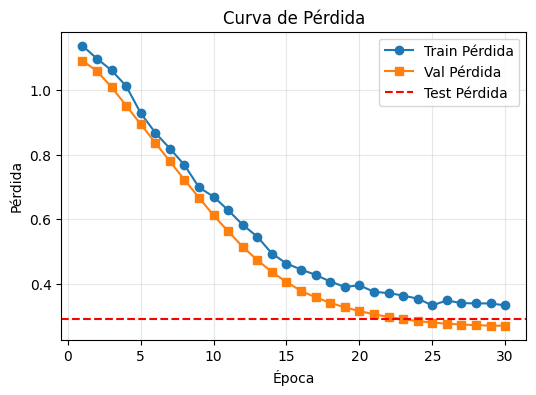

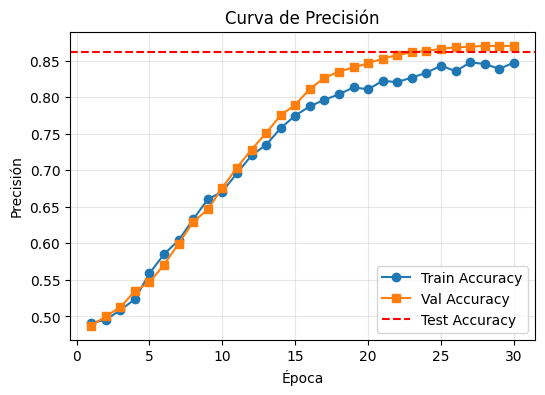

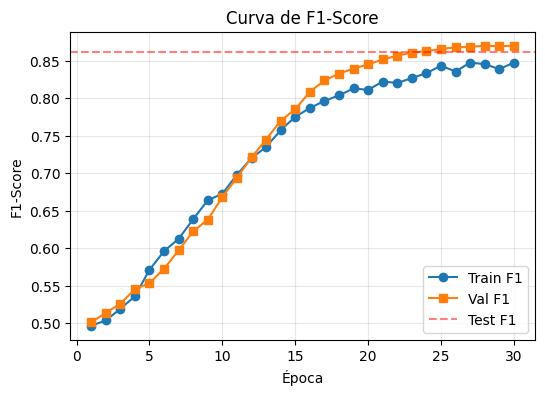

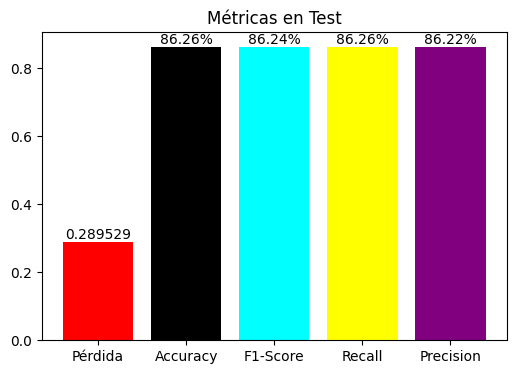

In [ ]:
# Asegurar que 'epoca' sea numérica
historia_tl["epoca"] = pd.to_numeric(historia_tl["epoca"], errors="coerce")
historia_tl = historia_tl.dropna(sub_conjunto=["epoca"])

# Gráfica de Pérdida (Train, Val, Test)
plt.figure(figsize=(6,4))
plt.plot(historia_tl.epoca, historia_tl.train_perdida, label="Train Pérdida", marker="o")
plt.plot(historia_tl.epoca, historia_tl.val_perdida, label="Val Pérdida", marker="s")
# Línea horizontal para test
plt.axhline(y=df_test.test_perdida.iloc[0], color="red", linestyle="--", label="Test Pérdida")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Curva de Pérdida")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Gráfica de Accuracy (Train, Val, Test)
plt.figure(figsize=(6,4))
plt.plot(historia_tl.epoca, historia_tl.train_acc, label="Train Accuracy", marker="o")
plt.plot(historia_tl.epoca, historia_tl.val_acc, label="Val Accuracy", marker="s")
# Línea horizontal para test
plt.axhline(y=df_test.test_acc.iloc[0], color="red", linestyle="--", label="Test Accuracy")
plt.xlabel("Época")
plt.ylabel("Precisión")
plt.title("Curva de Precisión")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Gráfica de F1-Score (Train, Val, Test)
plt.figure(figsize=(6,4))
plt.plot(historia_tl.epoca, historia_tl.train_f1, label="Train F1", marker="o")
plt.plot(historia_tl.epoca, historia_tl.val_f1, label="Val F1", marker="s")
# Línea horizontal para test
plt.axhline(y=df_test.test_f1.iloc[0], color="red", linestyle="--", label="Test F1",alpha=0.5)
plt.xlabel("Época")
plt.ylabel("F1-Score")
plt.title("Curva de F1-Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6,4))
valores = [df_test.test_perdida.iloc[0], df_test.test_acc.iloc[0], df_test.test_f1.iloc[0], df_test.test_recall.iloc[0], df_test.test_precision.iloc[0]]
etiq = ["Pérdida","Accuracy","F1-Score", 'Recall', 'Precision']
barras = plt.bar(etiq, valores, color=["red","black","cyan","yellow",'purple'])
plt.title("Métricas en Test")
# Añadir los valores encima de cada barra
for bar, valor, etiqueta in zip(barras, valores, etiq):
    if etiqueta == "Pérdida":
      texto = f"{valor:.6f}"
    else:
      texto = f"{valor*100:.2f}%"
    plt.text(
        bar.get_x() + bar.get_width()/2,   # posición x centrada
        bar.get_height(), # posición y en la altura de la barra
        texto, # formato del valor
        ha="center", va="bottom"           # alineación horizontal y vertical
    )
plt.show()


#### Matriz de confusión
---
En esta sección se muestra la matriz de confusión, la cual permite visualizar el desempeño del modelo en la clasificación de las clases “buen estado” y “defectuoso”, así como los errores cometidos en cada categoría.

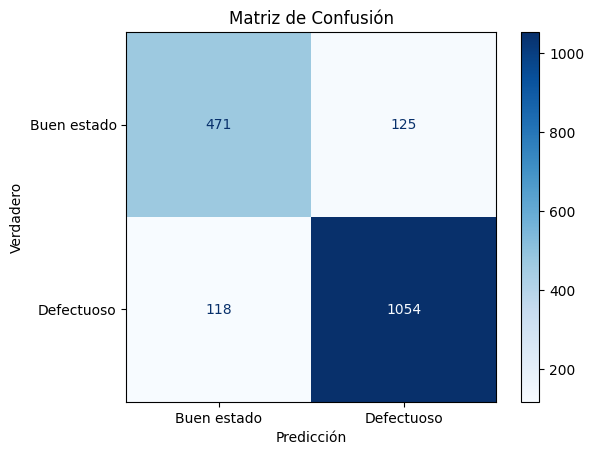

In [11]:
# Crear matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Mostrar matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Buen estado', 'Defectuoso'])
disp.plot(cmap=plt.cm.Blues)
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.title("Matriz de Confusión")
plt.show()

#### Ejemplo
---
En está sección se verifica la clasificación del modelo con un número de imágenes al azar.

Checkpoint cargado: /content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_tl.pt
Época: 30
   Mejor métrica: 0.8702


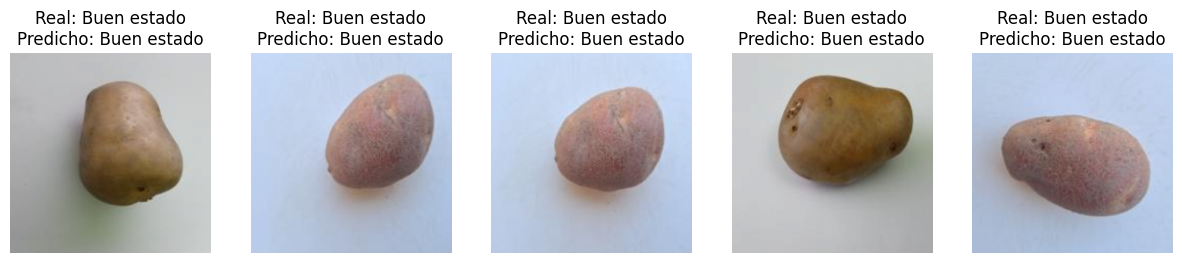

In [ ]:
# múmero de imágenes que quieres mostrar
num_img = 5

# tomamos un batch del test_loader
batch = next(iter(test_loader))
imagenes, etiquetas = batch[0].to(dispositivo), batch[1].to(dispositivo)
# cargar modelo
modelo = cargar_checkpoint(modelo_base, CHECKPOINT_RUTA)
# pasamos por el modelo
modelo.eval()
with torch.no_grad():
    salida = modelo(valores_pixel=imagenes)
    predicciones = salida.argmax(dim=1)

def denormalizar(img_tensor):
    media = np.array([0.485, 0.456, 0.406])
    desv_estandar = np.array([0.229, 0.224, 0.225])
    img = img_tensor.cpu().permute(1, 2, 0).numpy()
    img = desv_estandar * img + media   # revertir normalización
    img = np.clip(img, 0, 1) # asegurar rango válido
    return img

# mostrar las primeras 'num_img' imágenes con su predicción
fig, axes = plt.subplots(1, num_img, figsize=(15, 3))
for i in range(num_img):
    img = denormalizar(imagenes[i]) # de Tensor a formato imagen
    etiqueta_verdadera = train_ds.classes[etiquetas[i].cpu()]
    etiqueta_predicha = train_ds.classes[predicciones[i].cpu()]

    axes[i].imshow(img)
    axes[i].set_title(f"Real: {etiqueta_verdadera}\nPredicho: {etiqueta_predicha}")
    axes[i].axis("off")

plt.show()

#### Comprobando generalización del modelo
---
En esta sección se verifica la capacidad de generalización del modelo al clasificar imágenes externas al dataset original.

Checkpoint cargado: /content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_tl.pt
Época: 30
   Mejor métrica: 0.8702


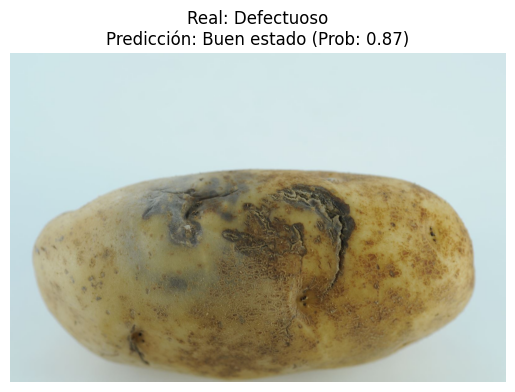

In [ ]:
def transformar_evaluar_img(img, ruta):
    transformar = create_transform(
        input_size=224,
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    )
    imagen_tensor = transformar(img)
    img_tensor = imagen_tensor.unsqueeze(0).to(dispositivo)
    modelo = cargar_checkpoint(modelo_base, ruta)
    modelo.eval()
    with torch.no_grad():
        salida = modelo(valores_pixel=img_tensor)
        pred = salida.argmax(dim=1).item()
        prob = salida.softmax(dim=1)[0][pred].item()

    clases = ["Buen estado", "Defectuoso"]
    eti_real = "Defectuoso"
    return img_tensor, pred, prob, clases, eti_real

img = Image.open("/content/drive/MyDrive/Datos_ViT/img/pod_cha.jpg").convert("RGB")
_, pred, prob, clases, eti_real = transformar_evaluar_img(img, CHECKPOINT_RUTA)
# mostrar imagen
plt.imshow(img)
plt.axis("off")
plt.title(f"Real: {eti_real}\nPredicción: {clases[pred]} (Prob: {prob:.2f})")
plt.show()

#### Grad-Camm
---
En esta sección se muestra el mapa de calor que utiliza el modelo para saber a qué parte de la imagen el modelo le presta más atención.

In [14]:
# ==========================================
# Funciones Auxiliares para ViT
# ==========================================
"""
    Transforma la salida plana de un Vision Transformer (ViT) a una estructura 2D.
    Necesario para que Grad-CAM/EigenCAM entiendan la geometría de la atención.
  """
def transformar_reshape(tensor, altura=224, anchura=224):
    # El tensor tiene forma [Batch, Tokens, Canales]
    # Eliminamos el token de clasificación [CLS] (índice 0)
    resultado = tensor[:, 1:, :]

    # Calculamos dinámicamente el tamaño de la cuadrícula (ej. 196 tokens -> 224x224)
    tamano_grid = int(np.sqrt(resultado.size(1)))

    # Reorganizamos: [Batch, Grid, Grid, Canales]
    resultado = resultado.reshape(tensor.size(0), tamano_grid, tamano_grid, tensor.size(2))

    # Transponemos para formato imagen: [Batch, Canales, Altura, Anchura]
    resultado = resultado.transpose(2, 3).transpose(1, 2)
    return resultado


# Define las transformaciones estándar para validación/inferencia en ViT
def obtener_transformacion():
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

# ==========================================
# Función de Visualización
# ==========================================
"""
    Genera y visualiza un mapa de atención (EigenCAM) para un modelo ViT.

    Parámetros:
        ruta_modelo (str): Ruta al archivo .pth del modelo entrenado.
        ruta_imagen (str): Ruta de la imagen a analizar.
        clase_real (str, opcional): Nombre de la clase real para mostrar en el título.
        dispositivo (torch.device, opcional): CPU o CUDA.
  """
def visualizar_iegencam(modelo, ruta_imagen, clase_real=None, dispositivo=None):

    if dispositivo is None:
        dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Cargar la imagen original (para visualización) y transformarla (para el modelo)
    imagen_pil = Image.open(ruta_imagen).convert("RGB")
    transformacion = obtener_transformacion()
    tensor_imagen = transformacion(imagen_pil).unsqueeze(0).to(dispositivo)

    # mover modelo
    modelo.to(dispositivo)
    modelo.eval()

    # Definir la capa objetivo para visualizar
    capas_objetivo = [modelo.backbone.blocks[-1].norm1]

    # Inicializar EigenCAM
    # Usamos EigenCAM porque genera mapas de calor más limpios para ViT que Grad-CAM
    cam = EigenCAM(
        model=modelo.backbone,
        target_layers=capas_objetivo,
        reshape_transform=transformar_reshape
    )

    # Generación del Mapa
    mapa_escala_grises = cam(input_tensor=tensor_imagen, targets=None)[0, :]

    # Obtener predicciones numéricas
    with torch.no_grad():
        salida = modelo(tensor_imagen)
        probs = torch.softmax(salida, dim=1).cpu().numpy()[0]
        indice_pred = np.argmax(probs)

    nombres_clases = ['Buen estado', 'Defectuoso']
    etiqueta_predicha = nombres_clases[indice_pred]
    confianza = probs[indice_pred]

    # imagen normalizada
    imagen_redimensionada = imagen_pil.resize((224, 224))
    imagen_normalizada = np.float32(imagen_redimensionada) / 255.0

    # superposición
    visualizacion = show_cam_on_image(imagen_normalizada, mapa_escala_grises, use_rgb=True)

    # Graficar Resultados
    fig, ejes = plt.subplots(1, 3, figsize=(12, 6))

    # Imagen Original
    titulo_real = f"\nReal: {clase_real}" if clase_real else ""
    ejes[0].imshow(imagen_redimensionada)
    ejes[0].axis("off")
    ejes[0].set_title(f"Imagen Original{titulo_real}", fontsize=12)

    # 2. Mapa de calor puro
    im = ejes[1].imshow(mapa_escala_grises, cmap='jet')
    ejes[1].axis("off")
    ejes[1].set_title(f"Mapa de Calor (EigenCAM)\nClase: {etiqueta_predicha}", fontsize=12)
    plt.colorbar(im, ax=ejes[1], fraction=0.046)

    # 3. Superposición sobre la imagen
    ejes[2].imshow(visualizacion)
    ejes[2].axis("off")
    ejes[2].set_title(
        f"Atención del Modelo\nPred: {etiqueta_predicha} ({confianza:.2%})",
        fontsize=12,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()

    # Retornamos valores por si se necesitan procesar después
    return etiqueta_predicha, confianza

#### Visualizar GradCam -> Transformer Learning
---
En esta sección se presenta el mapa de calor que refleja las áreas de atención del modelo en la imagen clasificada.

Checkpoint cargado: /content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_tl.pt
Época: 30
   Mejor métrica: 0.8702


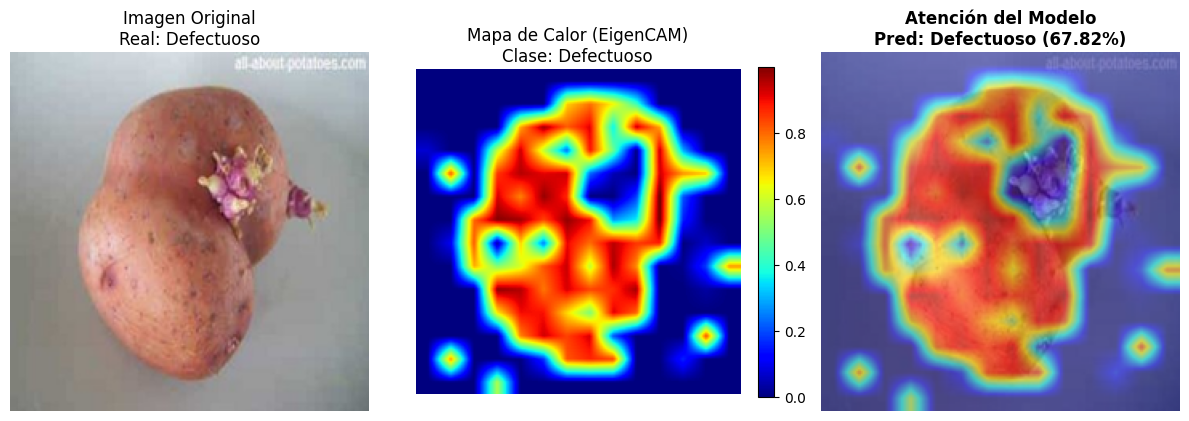

Predicción: Defectuoso (67.82%)


In [ ]:
# visualizar Grad-CAM en una imagen de ejemplo
ruta_img = "/content/drive/MyDrive/Datos_ViT/img/p_cho_b.jpg"
modelo = cargar_checkpoint(modelo_base, CHECKPOINT_RUTA)
etiqueta, confianza = visualizar_iegencam(modelo, ruta_img, "Defectuoso", dispositivo)
print(f"Predicción: {etiqueta} ({confianza:.2%})")

Fine Tuning parcial
---
En esta sección se implementa la técnica del fine-tuning parcial aplicado al modelo base (ViT-Base/16).

In [ ]:
dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# inicializar modelo para fine tuning parcial -> últimas 6 capas descongeladas
modelo_ft = ClasificadorPapasViT(num_clases=2, capas_descongelar=6).to(dispositivo)

# ====================================
# configuración de FINE-TUNING PARCIAL
# ====================================
config_ft = ConfigEntrenamiento(
    epocas=20,
    lr=1e-6,
    weight_decay=1e-4,
    batch_size=BATCH_SIZE,
    warmup_frac=0.5,
    mixed_precision=True,
    metrica_principal="f1"
)
# optimizador para fine-tuning
optimizador_ft = optim.AdamW(
    [p for p in modelo_ft.parameters() if p.requires_grad],
    lr=config_ft.lr,
    betas=config_ft.betas,
    weight_decay=config_ft.weight_decay
)
# entrenar capas finales con fine-tuning parcial
historia_ft, mejores_metricas_ft = entrenar_modelo(
    modelo=modelo_ft,
    train_loader=train_loader,
    val_loader=val_loader,
    criterio_perdida=criterio_perdida,
    optimizador=optimizador_ft,
    metricas=metricas,
    config=config_ft,
    ruta_ckpt=CHECKPOINT_FT,
    dispositivo=dispositivo,
    programador=None,
    escala=escala,
    descripcion=True
)
# mostrar métricas fine-tuning
display(pd.DataFrame(historia_ft))

Iniciando entrenamiento...

Configuración:
Épocas: 20
Learning Rate: 1e-06
Weight Decay: 0.0001
Batch Size: 32
Mixed Precision: True
Betas: (0.9, 0.999)
Warmup Frac: 0.5
Métrica Principal: f1

Metrica principal f1

Ruta checkpoint: /content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_ft.pt



Época 01/20 | 
Train → perdida: 0.4740 | acc: 0.7872 | f1: 0.7882 | precision: 0.7895 | recall: 0.7872
Val → perdida: 0.1481 | acc: 0.9399 | f1: 0.9400 | precision: 0.9401 | recall: 0.9399
✓ Mejor modelo guardado (época 1) → /content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_ft.pt
F1-Score: 0.9400
----------------------------------------------------------------------------------------------------


Época 02/20 | 
Train → perdida: 0.1992 | acc: 0.9126 | f1: 0.9127 | precision: 0.9128 | recall: 0.9126
Val → perdida: 0.0816 | acc: 0.9731 | f1: 0.9733 | precision: 0.9746 | recall: 0.9731
✓ Mejor modelo guardado (época 2) → /content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_ft.pt
F1-Score: 0.9733
----------------------------------------------------------------------------------------------------


Época 03/20 | 
Train → perdida: 0.1429 | acc: 0.9390 | f1: 0.9390 | precision: 0.9390 | recall: 0.9390
Val → perdida: 0.0508 | acc: 0.9844 | f1: 0.9845 | precision: 0.9848 | recall: 0.9844
✓ Mejor modelo guardado (época 3) → /content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_ft.pt
F1-Score: 0.9845
----------------------------------------------------------------------------------------------------


Época 04/20 | 
Train → perdida: 0.1286 | acc: 0.9462 | f1: 0.9462 | precision: 0.9463 | recall: 0.9462
Val → perdida: 0.0373 | acc: 0.9908 | f1: 0.9908 | precision: 0.9908 | recall: 0.9908
✓ Mejor modelo guardado (época 4) → /content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_ft.pt
F1-Score: 0.9908
----------------------------------------------------------------------------------------------------


...

Época 17/20 | 
Train → perdida: 0.0469 | acc: 0.9816 | f1: 0.9816 | precision: 0.9816 | recall: 0.9816
Val → perdida: 0.0017 | acc: 1.0000 | f1: 1.0000 | precision: 1.0000 | recall: 1.0000
✓ Mejor modelo guardado (época 17) → /content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_ft.pt
F1-Score: 1.0000
----------------------------------------------------------------------------------------------------


Época 18/20 | 
Train → perdida: 0.0413 | acc: 0.9834 | f1: 0.9834 | precision: 0.9834 | recall: 0.9834
Val → perdida: 0.0015 | acc: 1.0000 | f1: 1.0000 | precision: 1.0000 | recall: 1.0000
✓ Mejor modelo guardado (época 18) → /content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_ft.pt
F1-Score: 1.0000
----------------------------------------------------------------------------------------------------


Época 19/20 | 
Train → perdida: 0.0455 | acc: 0.9800 | f1: 0.9800 | precision: 0.9800 | recall: 0.9800
Val → perdida: 0.0016 | acc: 1.0000 | f1: 1.0000 | precision: 1.0000 | recall: 1.0000
----------------------------------------------------------------------------------------------------


Época 20/20 | 
Train → perdida: 0.0473 | acc: 0.9797 | f1: 0.9796 | precision: 0.9796 | recall: 0.9797
Val → perdida: 0.0031 | acc: 0.9993 | f1: 0.9993 | precision: 0.9993 | recall: 0.9993
----------------------------------------------------------------------------------------------------
Entrenamiento finalizado.
Mejor f1: 1.0000 (época 18)
Mejor pérdida: 0.001473



,epoca,train_perdida,train_acc,train_f1,train_precision,train_recall,val_perdida,val_acc,val_f1,val_precision,val_recall
0,1,0.473977,0.787230,0.788231,0.789534,0.787230,0.148055,0.939887,0.939993,0.940150,0.939887
1,2,0.199248,0.912628,0.912706,0.912796,0.912628,0.081563,0.973126,0.973329,0.974607,0.973126
2,3,0.142918,0.938981,0.939001,0.939022,0.938981,0.050779,0.984441,0.984495,0.984761,0.984441
3,4,0.128609,0.946233,0.946247,0.946261,0.946233,0.037336,0.990806,0.990813,0.990830,0.990806
4,5,0.106117,0.956137,0.956149,0.956161,0.956137,0.028623,0.992221,0.992234,0.992302,0.992221
5,6,0.102269,0.956845,0.956894,0.956965,0.956845,0.022633,0.996464,0.996465,0.996467,0.996464
6,7,0.083242,0.964981,0.964972,0.964964,0.964981,0.021191,0.995049,0.995046,0.995052,0.995049
7,8,0.085179,0.964273,0.964323,0.964405,0.964273,0.012659,0.998586,0.998585,0.998589,0.998586
8,9,0.071369,0.972232,0.972227,0.972222,0.972232,0.011149,0.998586,0.998585,0.998589,0.998586
9,10,0.068133,0.970994,0.971005,0.971019,0.970994,0.007225,0.997878,0.997878,0.997878,0.997878


#### Probar modelo entrenado con Fine Tuning parcial
---
En esta sección se evalúa el modelo obtenido durante el proceso de fine-tuning parcial, calculando las métricas de pérdida, precisión y F1-Score para medir su rendimiento final.

In [ ]:
modelo = cargar_checkpoint(modelo_ft, CHECKPOINT_FT)
ruta_dataset_test = Path("/content/drive/MyDrive/Datos_ViT/dataset_papas_local.zip")
# evaluar el modelo fine-tuned en test
metricas_test_ft, y_true_ft, y_pred_ft = evaluar_modelo(
    modelo=modelo,
    test_loader=cargar_datos_prueba(test_loader, DATA_DIR_ZIP=ruta_dataset_test),
    criterio_perdida=criterio_perdida,
    metricas=metricas,
    dispositivo=dispositivo,
    clases=train_ds.classes,
    mixed_precision=config_ft.mixed_precision,
    detallado=True
)
# crear DataFrame de métricas test fine-tuning
df_test_ft = pd.DataFrame([{f"test_{k}": v for k, v in metricas_test_ft.items()}])
display(df_test_ft)

Checkpoint cargado: /content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_ft.pt
Época: 18
   Mejor métrica: 1.0000



RESULTADOS EN TEST
Perdida: 0.0050
Acc: 0.9989
F1: 0.9989
Precision: 0.9989
Recall: 0.9989

Reporte de Clasificación:
              precision    recall  f1-score   support

 Buen estado       1.00      1.00      1.00       596
  Defectuoso       1.00      1.00      1.00      1172

    accuracy                           1.00      1768
   macro avg       1.00      1.00      1.00      1768
weighted avg       1.00      1.00      1.00      1768



,test_perdida,test_acc,test_f1,test_precision,test_recall
0,0.004992,0.998869,0.998869,0.998873,0.998869


#### Comparar resultados entre Transfer Learning y Fine-Tuning parcial
---
En esta sección se comparan los resultados obtenidos entre el modelo entrenado con Transfer Learning y el modelo entrenado con Fine Tuning parcial, analizando las diferencias en términos de precisión, F1-Score, Recall y Accuracy  para evaluar el desempeño de ambas técnicas.

In [18]:
"""
  Compara métricas entre Transfer Learning y Fine-Tuning.
  Args:
      df_tl: DataFrame con métricas de Transfer Learning
      df_ft: DataFrame con métricas de Fine-Tuning
      detallado: Imprimir comparación
  Returns:
      DataFrame con comparación lado a lado
  """
def comparar_resultados(
    df_tl: pd.DataFrame,
    df_ft: pd.DataFrame,
    detallado: bool = True
) -> pd.DataFrame:
    # Crear DataFrame de comparación
    comparacion = pd.DataFrame({
        'Transfer Learning': df_tl.iloc[0],
        'Fine-Tuning': df_ft.iloc[0]
    })

    # Calcular diferencias
    comparacion['Diferencia'] = comparacion['Fine-Tuning'] - comparacion['Transfer Learning']
    comparacion['Mejora (%)'] = (comparacion['Diferencia'] / comparacion['Transfer Learning']) * 100

    if detallado:
        print(f"\n{'===='*20}")
        print("COMPARACIÓN: TRANSFER LEARNING vs FINE-TUNING")
        print(f"{'===='*20}\n")

        print(comparacion.round(4).to_string())

        print(f"\n{'===='*20}")
        print("RESUMEN:")
        print(f"{'===='*20}")

        # Determinar cuál es mejor
        mejor_modelo = "Fine-Tuning" if comparacion.loc['test_f1', 'Fine-Tuning'] > comparacion.loc['test_f1', 'Transfer Learning'] else "Transfer Learning"
        print(f"Mejor modelo: {mejor_modelo}")
        print(f"Mejora en F1-Score: {comparacion.loc['test_f1', 'Diferencia']:.4f} ({comparacion.loc['test_f1', 'Mejora (%)']:.2f}%)")
        print(f"{'='*70}\n")

    return comparacion

# Usar la función
comparacion = comparar_resultados(df_test, df_test_ft, detallado=True)
display(comparacion)


COMPARACIÓN: TRANSFER LEARNING vs FINE-TUNING

                Transfer Learning  Fine-Tuning  Diferencia  Mejora (%)
test_perdida               0.2895       0.0050     -0.2845    -98.2760
test_acc                   0.8626       0.9989      0.1363     15.8033
test_f1                    0.8624       0.9989      0.1365     15.8304
test_precision             0.8622       0.9989      0.1367     15.8539
test_recall                0.8626       0.9989      0.1363     15.8033

RESUMEN:
Mejor modelo: Fine-Tuning
Mejora en F1-Score: 0.1365 (15.83%)



,Transfer Learning,Fine-Tuning,Diferencia,Mejora (%)
test_perdida,0.289529,0.004992,-0.284537,-98.275967
test_acc,0.862557,0.998869,0.136312,15.803275
test_f1,0.862355,0.998869,0.136514,15.830376
test_precision,0.862183,0.998873,0.136689,15.853873
test_recall,0.862557,0.998869,0.136312,15.803275


#### Gráficas
En esta parte se visualizan las gráficas correspondientes a las métricas obtenidas mediante transfer learning y fine-tuning parcial.

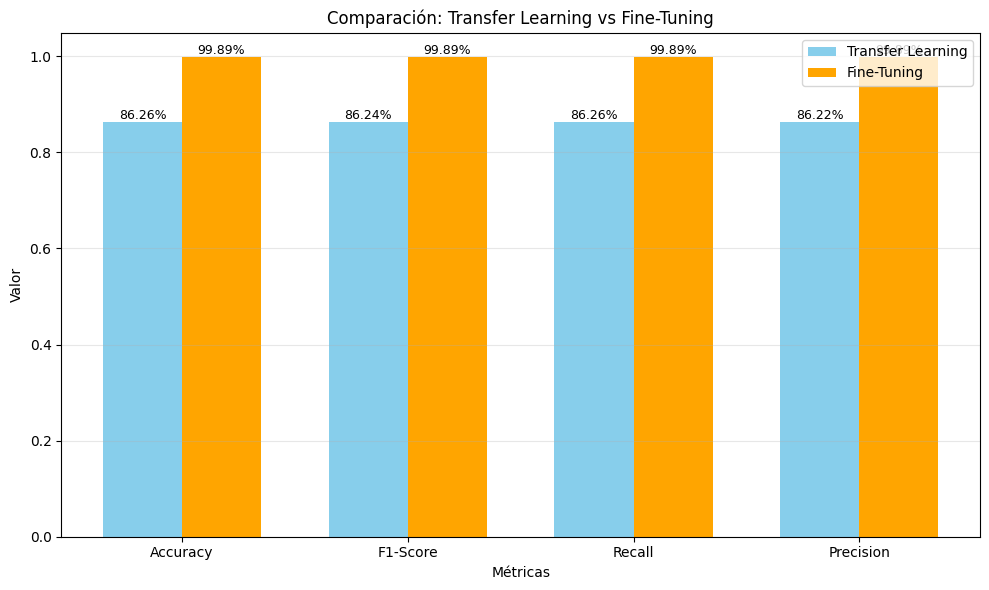

In [19]:
# Gráfica de barras comparativa
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

metricas_nombres = ['Accuracy', 'F1-Score', 'Recall', 'Precision']
x = np.arange(len(metricas_nombres))
width = 0.35

valores_tl = [df_test.test_acc.iloc[0], df_test.test_f1.iloc[0],
              df_test.test_recall.iloc[0], df_test.test_precision.iloc[0]]
valores_ft = [df_test_ft.test_acc.iloc[0], df_test_ft.test_f1.iloc[0],
              df_test_ft.test_recall.iloc[0], df_test_ft.test_precision.iloc[0]]

bars1 = ax.bar(x - width/2, valores_tl, width, label='Transfer Learning', color='skyblue')
bars2 = ax.bar(x + width/2, valores_ft, width, label='Fine-Tuning', color='orange')

# Añadir valores en las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height*100:.2f}%',
                ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Métricas')
ax.set_ylabel('Valor')
ax.set_title('Comparación: Transfer Learning vs Fine-Tuning')
ax.set_xticks(x)
ax.set_xticklabels(metricas_nombres)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#### Matriz de confusión
En esta sección se muestra las matrices de confusión para identificar verdaderos positivos y negativos entre las clases de clasificación, tanto con transfer learning como por fine-tuning parcial.

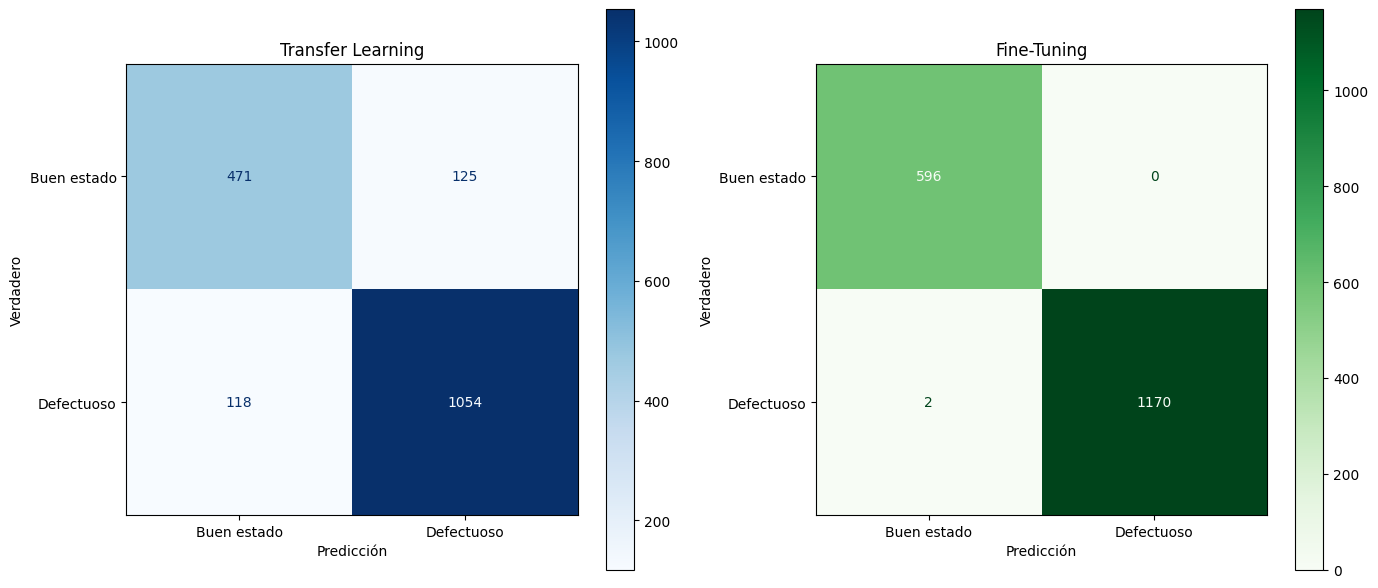

In [ ]:
# Crear matrices de confusión lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Transfer Learning
cm_tl = confusion_matrix(y_true, y_pred)
disp_tl = ConfusionMatrixDisplay(confusion_matrix=cm_tl, display_labels=['Buen estado', 'Defectuoso'])
disp_tl.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title('Transfer Learning')
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Verdadero")

# Fine-Tuning parcial
cm_ft = confusion_matrix(y_true_ft, y_pred_ft)
disp_ft = ConfusionMatrixDisplay(confusion_matrix=cm_ft, display_labels=['Buen estado', 'Defectuoso'])
disp_ft.plot(cmap=plt.cm.Greens, ax=axes[1])
axes[1].set_title('Fine-Tuning parcial')
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Verdadero")

plt.tight_layout()
plt.show()

#### Grad-CAM -> Fine-Tuning parcial
---
Visualizar mapa de atención de la imagen para identificar las áreas que el modelo considera más relevantes para la clasificación con fine-tuning parcial.

Checkpoint cargado: /content/drive/MyDrive/Datos_ViT/checkpoints/vit_papas_ft.pt
Época: 18
   Mejor métrica: 1.0000


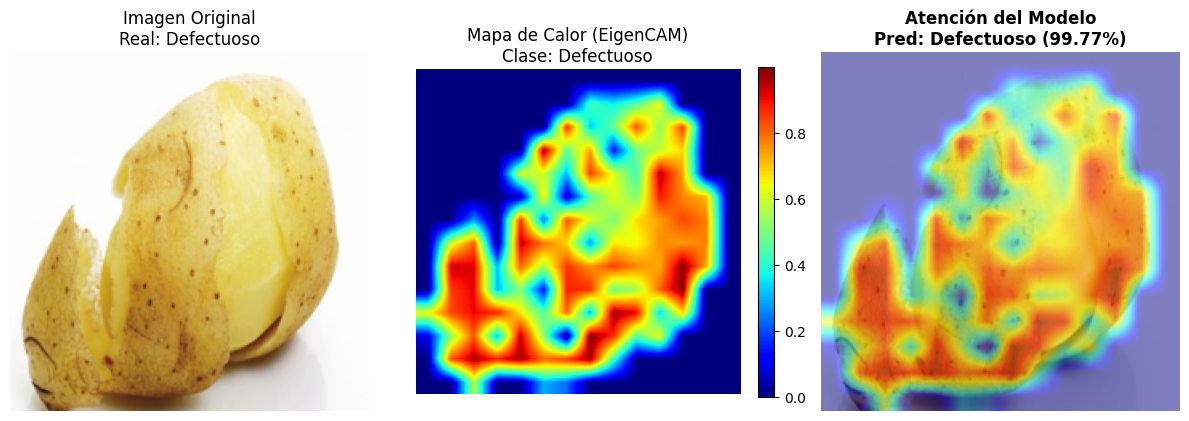

Predicción: Defectuoso (99.77%)


In [ ]:
# visualizar Grad-CAM en una imagen de ejemplo
ruta_img = "/content/drive/MyDrive/Datos_ViT/img/mal_cha.jpg"
modelo = cargar_checkpoint(modelo_base, CHECKPOINT_FT)
etiqueta, confi =visualizar_iegencam(modelo, ruta_img, "Defectuoso", dispositivo)
print(f"Predicción: {etiqueta} ({confi:.2%})")